<figure style="text-align: center;">
  <img src="_static/intro/title_page.png" style="display: block; margin: 0 auto; width: 100%;">
</figure>

### Spatial Trend Modeling, 2D + 1D = 3D

Michael J. Pyrcz, Professor, The University of Texas at Austin 

[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

Chapter of e-book "Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy". 

```{admonition} Cite this e-Book as:
:class: remove-from-content-only

Pyrcz, M.J., 2024, *Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy* [e-book]. Zenodo. doi:10.5281/zenodo.15169133 [![DOI](https://zenodo.org/badge/838927017.svg)](https://doi.org/10.5281/zenodo.15169132)  
```

The workflows in this book and more are available here:

```{admonition} Cite the GeostatsPyDemos GitHub Repository as:
:class: remove-from-content-only

Pyrcz, M.J., 2024, *GeostatsPyDemos: GeostatsPy Python Package for Spatial Data Analytics and Geostatistics Demonstration Workflows Repository* (0.0.1) [Software]. Zenodo. doi:10.5281/zenodo.12667036. GitHub Repository: https://github.com/GeostatsGuy/GeostatsPyDemos [![DOI](https://zenodo.org/badge/777871341.svg)](https://doi.org/10.5281/zenodo.12667035)



```

By Michael J. Pyrcz <br />
&copy; Copyright 2024.


In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
from shapely.geometry import Point
import matplotlib.pyplot as plt
import osmnx as ox
import time

ModuleNotFoundError: No module named 'geopandas'

This chapter is a tutorial for / demonstration of  **GIS Plotting** with a practical 2D + 1D approach. We assume that the 2D and 1D trends are calculated from data, we load the former and assume a simple function for the latter. 

**YouTube Lecture**: check out my lecture on [Trend Modeling](https://www.youtube.com/watch?v=BCnivpSKF18&list=PLG19vXLQHvSB-D4XKYieEku9GQMQyAzjJ&index=41). For convenience here's a summary of trend modeling.
#### GIS

Commonly our spatial data plotting can be improved through the integration of additional spatial data commonly stored in Geographic Information System (GIS) systems: 

* a framework of software, data, people, and methods used to collect, store, manage, analyze, and visualize data that are referenced to locations on the Earth.

* links spatial data (where things are) with attribute data (what things are like), enabling analysis and decision-making based on geographic relationships, patterns, and processes.

Key elements embedded in the definition:

* geographic / spatial reference: data are tied to coordinates (latitude–longitude, projected coordinates).

*data integration: combines maps, tables, remote sensing, GPS, and field data.

Analysis: supports operations like overlay, buffering, distance, interpolation, and spatial statistics.


Visualization & communication: maps, dashboards, and spatial models for insight and decisions.



In [1]:
#### Download drivable road network - Warning this will take a few minutes

In [6]:
G = ox.graph_from_place(
    place,
    network_type="drive",
    simplify=True
)

In [ ]:
#### Start Here

In [7]:
# Define Austin boundary
place = "Austin, Texas, USA"

# Convert to GeoDataFrame
roads = ox.graph_to_gdfs(G, nodes=False,)

# Keep only major roads
major_roads = roads[
    roads["highway"].isin(
        ["motorway", "trunk", "primary", "secondary"]
    )
]

# Project roads to Texas State Plane Central
major_roads = major_roads.to_crs(epsg=2277)

#### From Addresses to Lat and Long to Northings and Eastings

In [9]:
addresses = [
    "4801 La Crosse Ave, Austin, TX 78739",
    "2317 Speedway, Austin, TX",
    "401 Congress Ave, Austin, TX",
    "4100 River Place Blvd., Austin, TX",
]

df = pd.DataFrame({"Address": addresses})

geolocator = Nominatim(user_agent="austin_geocoder")

def geocode_address(addr, pause=1):
    try:
        loc = geolocator.geocode(addr)
        time.sleep(pause)  # be polite to OSM
        if loc:
            return loc.latitude, loc.longitude
    except GeocoderTimedOut:
        return geocode_address(addr, pause)
    return None, None

df[["Lat", "Long"]] = df["Address"].apply(
    lambda x: pd.Series(geocode_address(x))
)

gdf = gpd.GeoDataFrame(
    df,
    geometry=[Point(xy) for xy in zip(df.Long, df.Lat)],
    crs="EPSG:4326"
)

# Project to Texas State Plane Central (Austin)
gdf = gdf.to_crs(epsg=2277)

# Extract Easting / Northing
df["Easting"]  = gdf.geometry.x
df["Northing"] = gdf.geometry.y

points = gpd.GeoDataFrame(
    df,
    geometry=[Point(xy) for xy in zip(df.Easting, df.Northing)],
    crs="EPSG:2277"
)



,Address,Lat,Long,Easting,Northing
0,"4801 La Crosse Ave, Austin, TX 78739",30.185667,-97.873404,3.073757e+06,1.003986e+07
1,"2317 Speedway, Austin, TX",30.286229,-97.736580,3.116122e+06,1.007740e+07
2,"401 Congress Ave, Austin, TX",30.266284,-97.743114,3.114230e+06,1.007010e+07
3,"4100 River Place Blvd., Austin, TX",30.367759,-97.862323,3.075786e+06,1.010614e+07


In [12]:
df.head()

0    4801 La Crosse Ave, Austin, TX 78739
1               2317 Speedway, Austin, TX
2            401 Congress Ave, Austin, TX
3      4100 River Place Blvd., Austin, TX
Name: Address, dtype: object

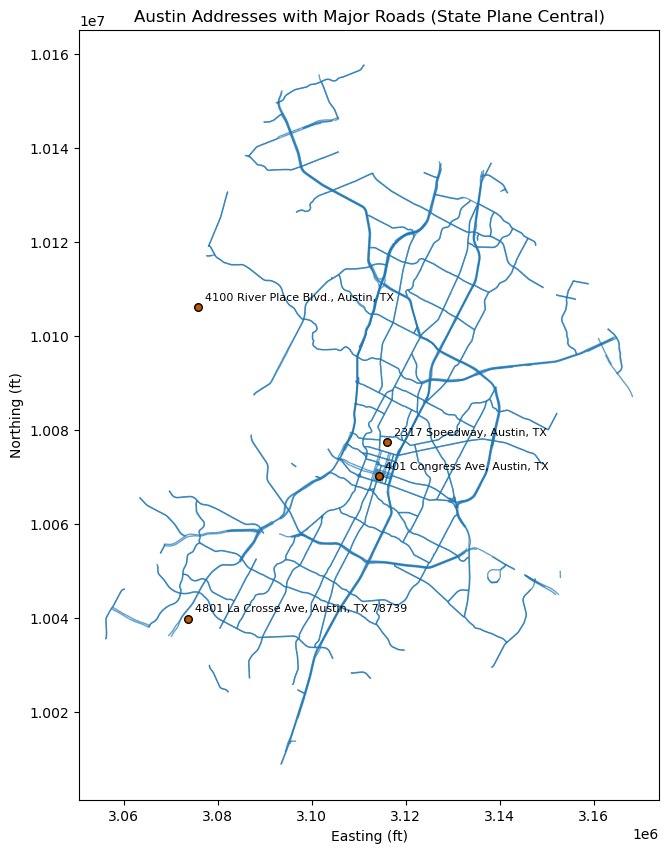

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot roads
major_roads.plot(
    ax=ax,
    linewidth=1,
    alpha=0.7
)

# Plot points
points.plot(ax=ax,markersize=30,color='#BF5700',edgecolor='black',alpha=1.0,zorder=10)

# Add annotations
for _, row in points.iterrows():
    ax.annotate(
        text=row["Address"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),          # offset in points
        textcoords="offset points",
        fontsize=8,
        color="black"
    )


ax.set_title("Austin Addresses with Major Roads (State Plane Central)")
ax.set_xlabel("Easting (ft)")
ax.set_ylabel("Northing (ft)")
ax.set_aspect("equal")

plt.show()

In [16]:
points

,Address,Lat,Long,Easting,Northing,geometry
0,"110 Inner Campus Dr, Austin, TX",30.286071,-97.739352,3.115249e+06,1.007732e+07,POINT (3115249.053 10077324.947)
1,"2317 Speedway, Austin, TX",30.286229,-97.736580,3.116122e+06,1.007740e+07,POINT (3116122.435 10077402.733)
2,"401 Congress Ave, Austin, TX",30.266284,-97.743114,3.114230e+06,1.007010e+07,POINT (3114229.614 10070103.017)
3,"4100 River Place Blvd., Austin, TX",30.367759,-97.862323,3.075786e+06,1.010614e+07,POINT (3075785.855 10106143.14)
